# [LAB-13] 4. 시계열의 통계적 접근 - 연습문제

## 준비작업

### 라이브러리 참조

In [1]:
from jussam import load_data
from helpers import *

📦 연세대학교 주영아 교수가 제작한 라이브러리를 사용중입니다.
📧 Email(1): j.purplerose@yonsei.ac.kr
📧 Email(2): j.purplerose@gmail.com
📝 Website: https://juyounga.kr/
🔖 Version: 0.5.19


## 📚 서울 기온 보고서 — 그래서 내년 여름은 얼마나 더운가

### 당신은 서울시 기후정책과에서 기온 분석을 맡고 있는 연구원입니다.

지난 보고에서 사무관의 물음에는 모두 답했습니다. 1단원에서 이 자료의 정상성을 판정했고($d=0$, $D=1$, $s=12$), 2단원에서는 창 크기 12의 이동평균으로 50년간 **+2.830℃** 의 상승을 찾아냈으며, 3단원에서는 추세 · 계절 · 잔차로 분해해 계절이 얼마나 큰지까지 숫자로 보여주었습니다.

보고서를 덮으며 사무관이 말합니다. "지나간 50년은 이제 알겠습니다. 그런데 시민들이 정작 묻는 건 '그래서 내년 여름은 얼마나 더운가'입니다. 예측치를 넣어 주세요."

예측 모형을 세우려면 모형에 넣을 **차수**부터 찾아야 합니다. 다만 사무관이 한마디 덧붙입니다. "인계받은 전처리를 그대로 믿지 말고, 원본부터 다시 확인하고 시작하세요."

시계열 분석의 표준 절차 **① 계절 주기 확인 · 분해 → ② 차분 → ③ ACF · PACF → ④ ARIMA** 를 따라, ③번까지 밟아 차수 후보를 확정하세요.

### 💻 코드 작성

#### 데이터 가져오기 및 인덱스 설정

In [8]:
origin = load_data('temperatures_seoul')

df = my_ts.set_index(origin, "날짜", freq="MS")

print(f"데이터셋 크기: {df.shape[0]}행 | 기간: {df.index[0]:%Y-%m} ~ {df.index[-1]:%Y-%m}")

df.head()

📚 1973년 1월부터 2023년 8월까지 서울의 월평균 기온 데이터 (출처: 기상청)
데이터셋 크기: 602행 | 기간: 1973-07 ~ 2023-08


,평균기온(℃)
날짜,
1973-07-01,26.816
1973-08-01,25.884
1973-09-01,20.323
1973-10-01,13.039
1973-11-01,4.723


#### 계절 주기 확인 — 창 크기를 바꿔가며 비교

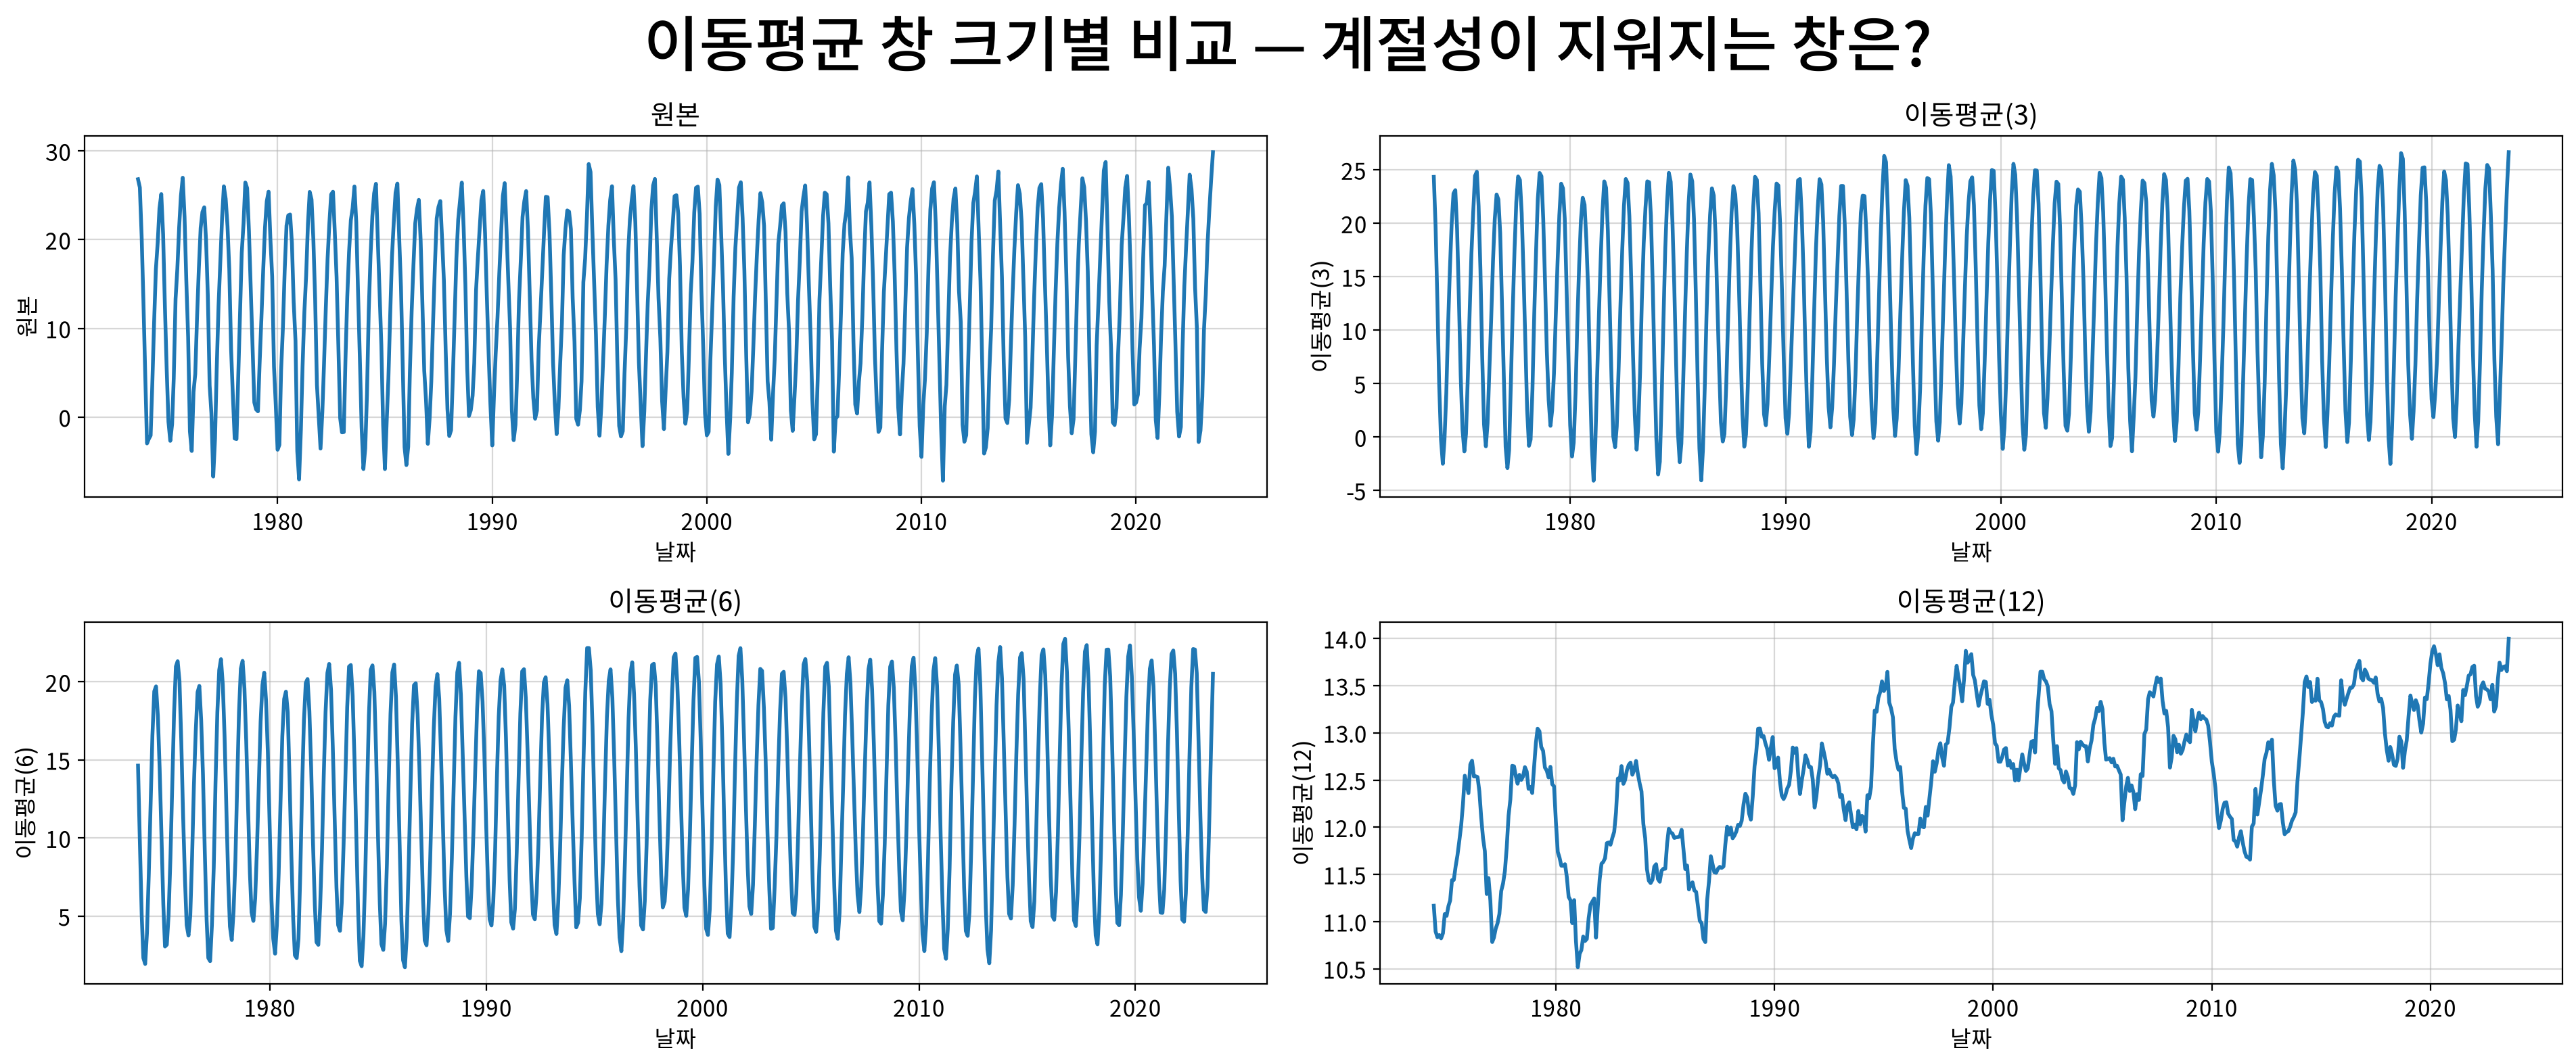


창 크기별 잔여 표준편차
  원본           9.932
  이동평균(3)      8.970
  이동평균(6)      6.332
  이동평균(12)     0.745


In [9]:
# 창 크기를 계절 주기와 같게 잡으면 계절성이 완전히 지워진다
smoothed = my_ts.compare_smoothing(df, (3, 6, 12), "평균기온(℃)", method="ma",
                                   title="이동평균 창 크기별 비교 — 계절성이 지워지는 창은?")

# 지워졌는지는 남은 변동의 크기로 확인한다
print("\n창 크기별 잔여 표준편차")

for c in smoothed.columns:
    print(f"  {c:<12} {smoothed[c].std():.3f}")

#### 로그변환 여부 확인 — 분해 시계열(추세 · 계절 · 잔차)

결합 방식 자동 판정: additive
관측치 602개 중 추세·잔차가 계산된 구간 590개


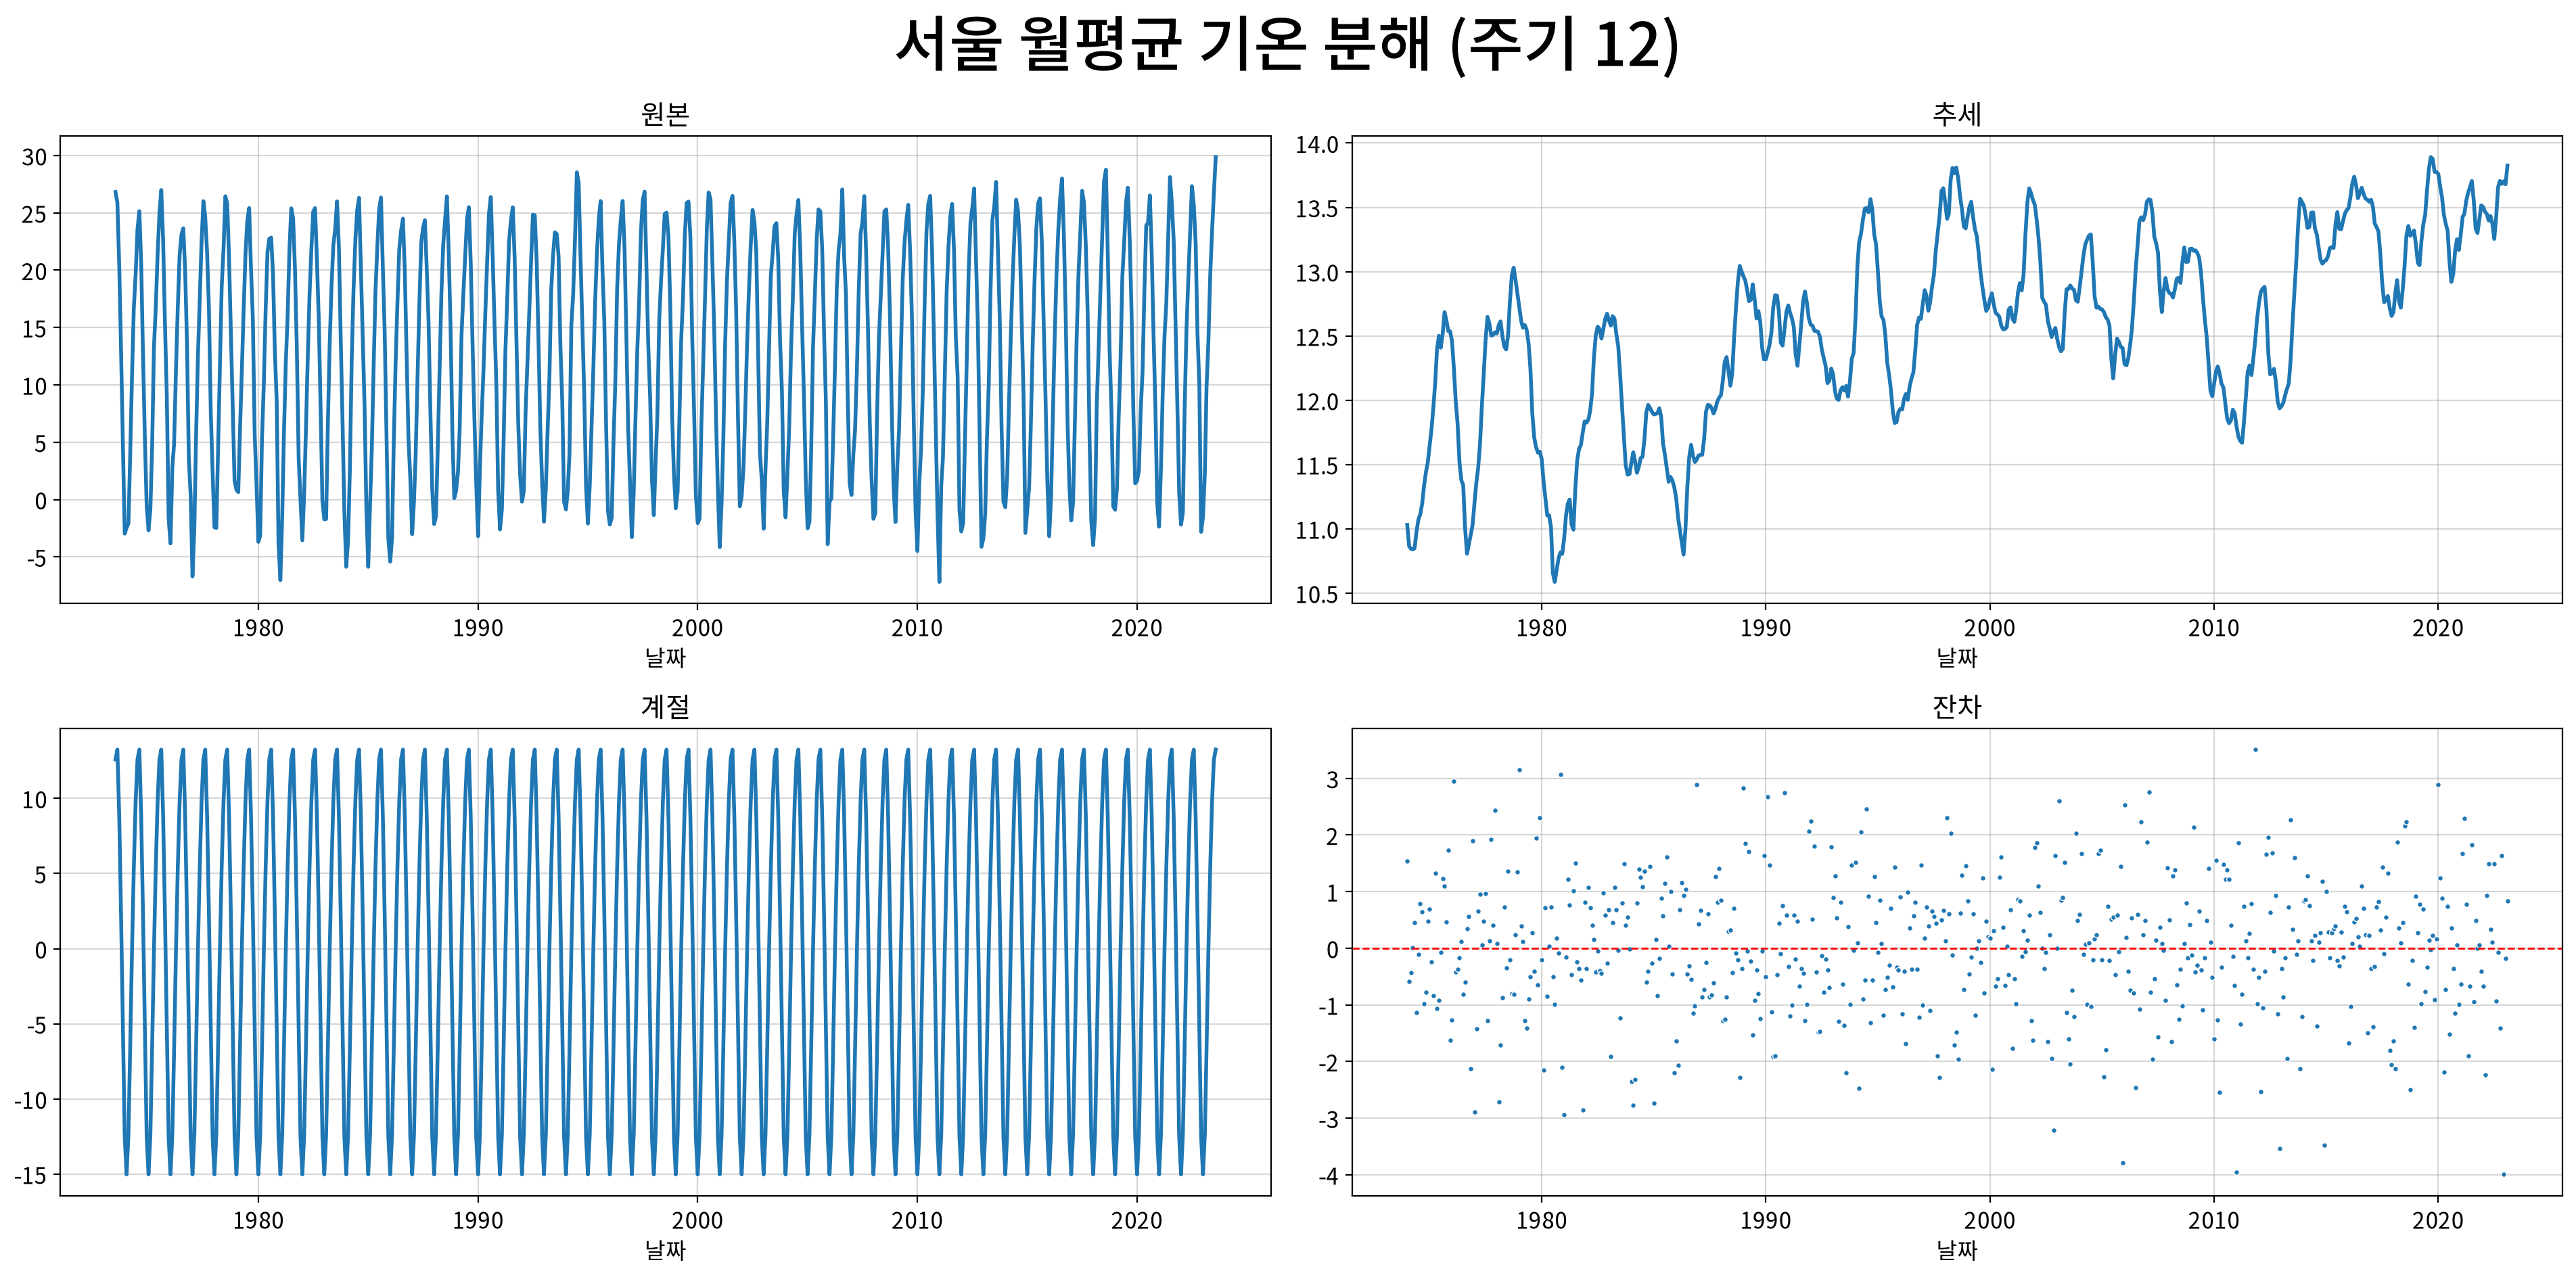

,원본,추세,계절,잔차
count,590.000,590.000,590.000,590.000
mean,12.513,12.562,-0.046,-0.002
std,9.912,0.739,9.813,1.213
min,-7.184,10.587,-15.024,-3.994
25%,3.042,12.070,-12.361,-0.756
50%,13.674,12.633,-0.136,0.036
75%,21.838,13.165,8.773,0.743
max,28.761,13.891,13.246,3.507


In [10]:
# model 을 주지 않으면 가법 / 승법을 스스로 판정한다
sd = my_ts.decompose(df, 12, "평균기온(℃)",
                     title="서울 월평균 기온 분해 (주기 12)")

sd.dropna().describe().round(3)

#### 차분 — 전처리 조합 자동 탐색

In [11]:
# 로그 여부 × 일반차분 0~2회 × 계절차분 0~1회 조합을 모두 검정한다
stationary = my_ts.adf_transform(df, "평균기온(℃)", log=False, period=12, max_diff=2)

print(f"\n1순위 조합을 적용한 결과 관측치: {len(stationary)}개")

조합 6개 중 정상 6개
권장 전처리: 계절차분(12)


,관측치 수,검정통계량(ADF),p-value,사용 시차,1% 기각값,5% 기각값,10% 기각값,표준편차,정상성,판정
계절차분(12),590,-8.829,0.000,12,-3.442,-2.867,-2.569,1.881,True,정상
1차 차분 + 계절차분(12),589,-10.251,0.000,19,-3.442,-2.867,-2.569,2.371,True,정상
2차 차분,600,-13.340,0.000,18,-3.442,-2.867,-2.569,3.982,True,정상
2차 차분 + 계절차분(12),588,-10.171,0.000,19,-3.442,-2.867,-2.569,4.010,True,정상
1차 차분,601,-10.529,0.000,13,-3.442,-2.866,-2.569,5.407,True,정상
원본,602,-3.877,0.002,14,-3.442,-2.866,-2.569,9.932,True,정상



1순위 조합을 적용한 결과 관측치: 590개


#### ACF · PACF — 차수 판정

관측치 590개 | 유의성 기준값 0.082 | 최대 시차 36 (상한 N/4=147)
AR 차수 후보 (p): 1   ← PACF가 lag 1 이후 절단
MA 차수 후보 (q): 3   ← ACF가 lag 3 이후 절단
계절 AR 차수 후보 (P): 3   ← 계절 PACF가 lag 36 이후 절단 (판정 시차 [12, 24, 36])
계절 MA 차수 후보 (Q): 2   ← 계절 ACF가 lag 24 이후 절단 (판정 시차 [12, 24, 36])
→ SARIMA(1, d, 3)(3, D, 2)[12] — d·D 는 차분 단계의 결과를 넣는다


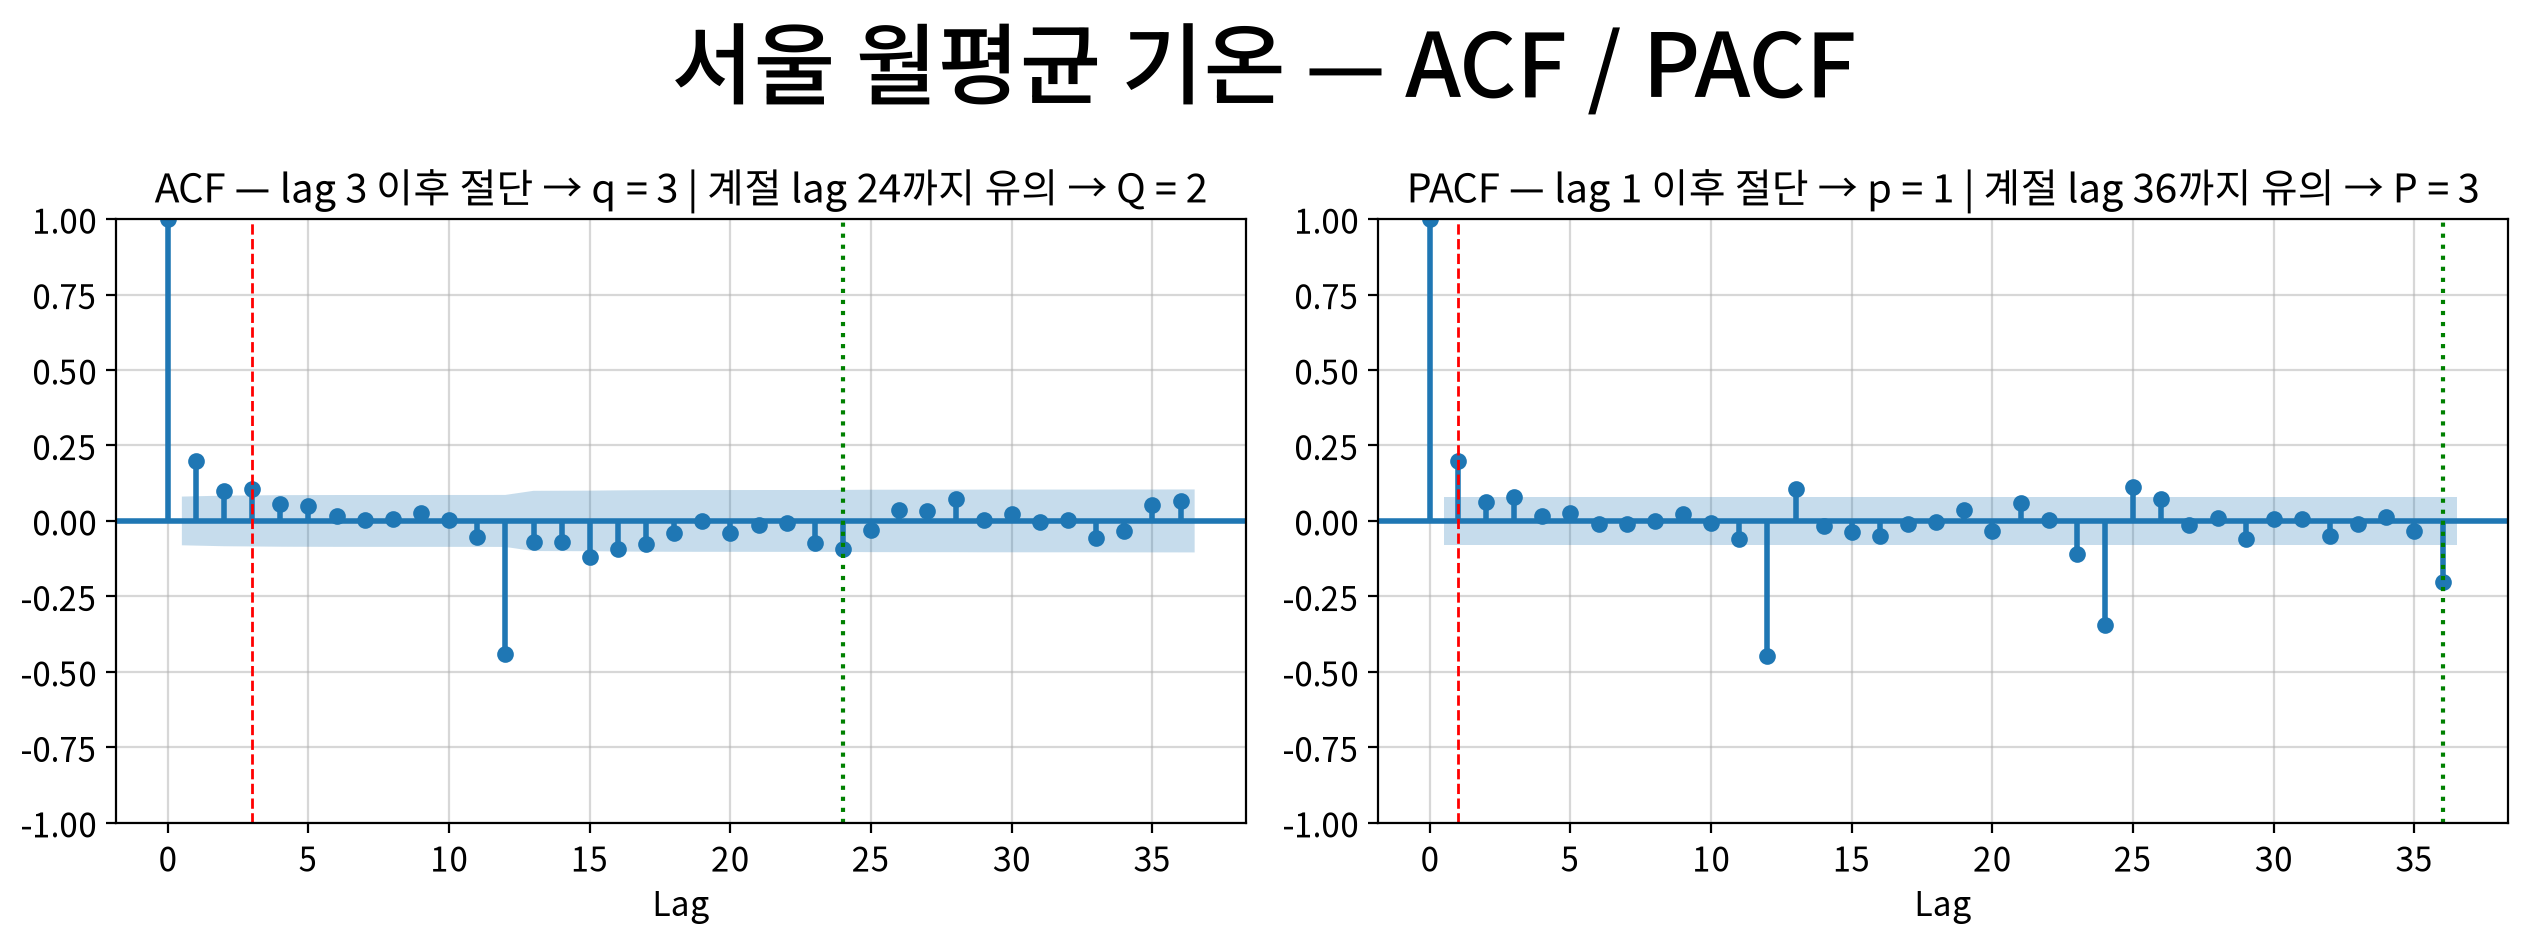

,acf,acf 유의성,pacf,pacf 유의성,기준값,p,q,P,Q
lag,,,,,,,,,
1,0.200,True,0.200,True,0.082,◀,,,
2,0.099,True,0.061,False,0.082,,,,
3,0.105,True,0.078,False,0.082,,◀,,
4,0.056,False,0.018,False,0.082,,,,
5,0.051,False,0.026,False,0.082,,,,
6,0.017,False,-0.009,False,0.082,,,,
7,0.002,False,-0.010,False,0.082,,,,
8,0.005,False,-0.001,False,0.082,,,,
9,0.025,False,0.024,False,0.082,,,,


In [12]:
order_df = my_ts.auto_correlation(stationary, period=12,
                                  rows=1, cols=2, width=640, height=480,
                                  title="서울 월평균 기온 — ACF / PACF")

order_df

### 문제 풀이

#### 1. 먼저 계절 주기부터 확정해야 합니다. 이동평균의 창 크기를 바꿔가며 비교했을 때, 계절성이 완전히 지워지는 창 크기는 얼마인가요?

- **정답**: `12`
- **복습 개념**: 계절 주기 판정입니다. **창 크기를 계절 주기와 같게 잡으면 한 주기가 통째로 평균되어 계절성이 상쇄**됩니다. 성수기와 비수기가 서로 지워지기 때문입니다.
- **풀이 접근**: 창 크기를 3 · 6 · 12로 바꿔가며 평활한 뒤, 각 결과에 남은 변동(표준편차)을 비교합니다. 계절성이 지워지면 변동이 급격히 줄어듭니다.
- **근거(계산 결과)**: 원본 9.932 → 창 3에서 8.970 → 창 6에서 6.332 로 조금씩만 줄다가, **창 12에서 0.745 로 급락**합니다. 월간 자료이므로 주기는 **12개월**이며, 인계받은 $s=12$ 가 맞습니다.
- **헷갈리기 쉬운 점**: 창 6에서도 변동이 꽤 줄어드니 6을 답하기 쉽습니다. 하지만 6개월 평균은 **반 년치만 상쇄**해 여름과 겨울 중 한쪽만 지웁니다. 그래프에서도 창 6은 봉우리가 절반 크기로 남아 있고, 창 12에서야 평평한 선이 됩니다. 창 크기는 반드시 **주기 또는 그 배수**로 잡아야 합니다.

#### 2. 이 자료는 가법과 승법 중 어느 쪽으로 판정되나요?

- **정답**: `가법`
- **복습 개념**: 가법(additive)과 승법(multiplicative)의 구분입니다. **변동폭이 수준에 비례해 커지면 승법**, 수준과 무관하게 일정하면 가법입니다. 승법일 때만 로그변환이 필요합니다.
- **풀이 접근**: 주기 12로 분해를 수행하되 결합 방식을 지정하지 않으면, 연도별 변동을 비교해 스스로 판정합니다. 출력의 판정 문장을 읽습니다.
- **근거(계산 결과)**: `결합 방식 자동 판정: additive` → **가법**입니다. 계절 성분의 평균이 −0.046 으로 **0 주변**인 것도 가법의 특징입니다. (승법이면 1 주변입니다.)
- **함께 생각해 볼 점**: 항공 승객 데이터는 승객이 늘수록 성수기 진폭도 함께 커져 승법이었습니다. 기온은 다릅니다. 30℃ 언저리의 흔들림과 0℃ 언저리의 흔들림이 비슷한 크기이기 때문입니다. **같은 절차를 밟아도 데이터가 다르면 처방이 달라집니다.**

#### 3. 기온에는 음수가 있어 로그변환을 후보에서 제외하고 전처리 조합을 탐색했습니다. 1순위로 추천된 조합을 적용하면 관측치가 몇 개 남나요?

- **정답**: `590`
- **복습 개념**: 계절차분의 관측치 소실입니다. 12개월 전 값을 빼는 연산이므로 앞쪽 **주기 길이만큼**이 사라집니다. 일반차분이 1개를 잃는 것과 같은 이치입니다.
- **풀이 접근**: 로그변환을 뺀 채로 일반차분 0~2회 × 계절차분 0~1회 조합을 모두 검정하게 하고, 1순위로 추천된 조합을 적용한 결과의 길이를 셉니다.
- **근거(계산 결과)**: `조합 6개 중 정상 6개` 가운데 **`권장 전처리: 계절차분(12)`** 가 1순위입니다. 602 − 12 = **590개**이며 출력의 `1순위 조합을 적용한 결과 관측치: 590개` 로 확인됩니다.

일반차분을 섞은 조합들도 모두 정상 판정을 받지만, **필요한 만큼만 차분하는 것**이 원칙이므로 가장 적게 손대고 정상성을 얻은 조합이 선택됩니다.
- **자주 하는 실수**: 1개만 줄어든다고 답하기 쉽습니다. 그건 일반차분일 때 이야기이고, 계절차분은 **주기 수만큼** 잃습니다. 주기가 12면 12개, 주기가 7이면 7개입니다.

그리고 탐색에서 로그변환을 뺀 이유도 기억하세요. **기온에는 음수가 있습니다.** 최저 −7.184℃ 이므로 로그를 씌우면 겨울 달이 통째로 결측이 되어 버려집니다. 로그변환은 **양수 데이터에만** 쓸 수 있습니다.

#### 4. 정상 시계열에서 자기상관이 이어지다 처음으로 끊기는 지점을 찾으면, 비계절 MA 차수 후보는 얼마인가요?

- **정답**: `3`
- **복습 개념**: MA(q)는 **ACF가 시차 q 이후 절단**되는 성질을 갖습니다. "직전 시차는 유의한데 현재 시차는 비유의"가 되는 첫 자리를 찾고, 그 **직전 시차**가 차수입니다.
- **풀이 접근**: 정상 시계열의 자기상관을 시차 1부터 순서대로 확인하며, 유의 → 비유의로 바뀌는 첫 지점을 찾습니다. 그 지점의 바로 앞 시차가 답입니다.
- **근거(계산 결과)**: 관측치 590개이므로 유의성 기준값은 $2/\sqrt{590} = 0.082$ 입니다. ACF는 lag 1 = 0.200, lag 2 = 0.099, lag 3 = 0.105 로 셋 다 기준값을 넘고 **lag 4 = 0.056 에서 처음 음영 안으로 들어갑니다.** 절단 지점이 lag 4이므로 차수는 그 직전인 **3** 입니다. 결과표의 `q` 열 표시와 일치합니다.
- **자주 하는 실수**: 절단 지점의 시차 번호인 4를 그대로 답하기 쉽습니다. 차수는 "유의한 구간이 어디까지였는가"이므로 **끊긴 자리가 아니라 그 직전**입니다.

#### 5. 중간 시차의 영향을 걷어내고 본 부분자기상관에서는, 비계절 AR 차수 후보가 얼마로 나오나요?

- **정답**: `1`
- **복습 개념**: AR(p)는 **PACF가 시차 p 이후 절단**됩니다. ACF가 간접 영향까지 포함한 값이라면, PACF는 중간 시차를 통제하고 남은 **직접적인** 관계만 봅니다.
- **풀이 접근**: ACF와 같은 규칙을 PACF에 적용합니다. 유의 → 비유의로 바뀌는 첫 지점의 직전 시차를 읽습니다.
- **근거(계산 결과)**: PACF는 lag 1 = 0.200 만 유의하고 **lag 2 = 0.061 에서 바로 음영 안으로 들어갑니다.** 절단 지점이 lag 2이므로 차수는 **1** 입니다.

ACF는 lag 3까지 이어졌는데 PACF는 lag 1에서 끊긴 것이, 2 · 3차의 상관이 **lag 1을 통해 전달된 간접 영향**이었음을 보여줍니다.
- **헷갈리기 쉬운 점**: ACF는 3, PACF는 1로 서로 다르게 나왔습니다. 어느 하나가 틀린 게 아닙니다. **ACF는 q를, PACF는 p를 알려주는 서로 다른 도구**이므로 값이 달라도 정상입니다. 둘 다 서서히 감소한다면 그때는 AR과 MA를 함께 쓰는 경우입니다.

#### 6. 지금까지 본 것은 이웃한 시차뿐입니다. 계절 주기의 배수 시차(12 · 24 · 36)만 따로 모아 같은 판정을 적용하면, 계절 AR 차수 후보 P 와 계절 MA 차수 후보 Q 는 각각 얼마인가요?

- **정답**: `P = 3, Q = 2`
- **복습 개념**: 계절 차수 판정입니다. 소문자 p · q 가 **지난달**과의 관계라면, 대문자 P · Q 는 **작년 같은 달**과의 관계입니다. 규칙은 똑같고 **세는 단위만 1시차에서 1주기로 바뀝니다.** 최종 모형은 $SARIMA(p, d, q)(P, D, Q)_{s}$ 형태가 됩니다.
- **풀이 접근**: 결과표에서 주기의 배수인 lag 12 · 24 · 36 행만 골라 봅니다. 1배수(12)부터 차례로 훑다가 처음 비유의를 만나면 절단이고, **거기까지 연속으로 유의했던 배수의 개수**가 차수입니다. 계절 ACF 는 Q, 계절 PACF 는 P 를 알려줍니다.
- **근거(계산 결과)**: 기준값은 앞 문제와 같은 0.082 입니다.

| 계절 시차 | acf | pacf | 판정 |
|---|---|---|---|
| 12 (1배수) | **−0.441** | **−0.458** | 둘 다 유의 |
| 24 (2배수) | **−0.094** | **−0.364** | 둘 다 유의 |
| 36 (3배수) | 0.067 | **−0.229** | acf 만 비유의 → **여기서 ACF 절단** |

계절 ACF 는 24까지 이어지다 36에서 끊기므로 **Q = 2**, 계절 PACF 는 36까지 끊기지 않으므로 **P = 3** 입니다. 결과표의 `Q` 열은 lag 24, `P` 열은 lag 36 에 표시됩니다.
- **자주 하는 실수**: 끊긴 시차 번호인 36 을 그대로 답하기 쉽습니다. 대문자 차수는 **시차 번호가 아니라 배수의 개수**입니다. lag 24 까지 유의했다면 24 가 아니라 **2** 입니다.
- **헷갈리기 쉬운 점**: P = 3 은 "3주기까지 유의하다"가 아니라 **"판정 범위 안에서는 끊기지 않았다"** 는 뜻입니다. 실제로 계절 PACF 는 −0.458 → −0.364 → −0.229 로 **서서히 작아지는 tail-off** 모양입니다. 절단이 아니라 감소이므로, 계절 쪽은 AR 이 아니라 **MA(Q) 가 주도**한다고 읽는 것이 맞습니다.
- **함께 생각해 볼 점**: lag 24 의 acf −0.094 는 기준값 0.082 를 간신히 넘긴 경계선 값입니다. 이것을 무시하면 Q = 1 이 됩니다. **ACF · PACF 는 정답을 찍어주지 않고 후보의 상한만 좁혀줍니다.** P = 3, Q = 2 를 상한으로 두고 그 안의 조합을 모두 적합해 AIC · BIC 로 고르는 것이 5단원의 일입니다.